<a href="https://colab.research.google.com/github/ayrous02/YSP_2025/blob/main/%5BYSP%5D_Nikolic_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
#Aminoacids Molecules

involved in biological process


In [ ]:
#I'm think on diving them by class (non polar, polar.., essential, non essential)

aasmiles = {
    "A": "CC(C(=O)O)N",                      # Alanine
    "R": "C(CC(C(=O)O)N)CN=C(N)N",          # Arginine
    "N": "C(C(C(=O)O)N)C(=O)N",             # Asparagine
    "D": "C(C(C(=O)O)N)C(=O)O",             # Aspartic acid
    "C": "C(C(C(=O)O)N)S",                  # Cysteine
    "Q": "C(CC(=O)N)C(C(=O)O)N",            # Glutamine
    "E": "C(CC(=O)O)C(C(=O)O)N",            # Glutamic acid
    "G": "C(C(=O)O)N",                      # Glycine
    "H": "C1=C(NC=N1)CC(C(=O)O)N",          # Histidine
    "I": "CCC(C)C(C(=O)O)N",                # Isoleucine
    "L": "CC(C)CC(C(=O)O)N",                # Leucine
    "K": "C(CCN)CC(C(=O)O)N",               # Lysine
    "M": "CSCCC(C(=O)O)N",                  # Methionine
    "F": "C1=CC=C(C=C1)CC(C(=O)O)N",        # Phenylalanine
    "P": "C1CC(NC1)C(=O)O",                 # Proline
    "S": "C(C(C(=O)O)N)O",                  # Serine
    "T": "CC(C(C(=O)O)N)O",                 # Threonine
    "W": "C1=CC=C2C(=C1)C(=CN2)CC(C(=O)O)N", # Tryptophan
    "Y": "C1=CC(=CC=C1CC(C(=O)O)N)O",       # Tyrosine
    "V": "CC(C)C(C(=O)O)N",                 # Valine
}

In [ ]:
# As we talked in the previous meeting, we're going to divide the aminoacids between
# proteinogenic, non-proteinogenic, meteorites and in silico generated

#smiles for:

am_proteinogenic = {
}

am_non_proteinogenic = {
}

am_meteorites = {
}

am_in_silico_generated = {
}


---
# Tester Molecules

**Division by structural classes 🔎[based on google sheets](https://docs.google.com/spreadsheets/d/1UZZN2DB5ETuu4cb01hXS3Th1kwTZSR5eOoiX8avnTAA/edit?usp=sharing)**

In [ ]:
alkanes = {
    "methane": "C",
    "ethane": "CC",
    "propane": "CCC",
    "butane": "CCCC",
    "pentane": "CCCCC",
    "hexane": "CCCCCC",
    "heptane": "CCCCCCC",
    "octane": "CCCCCCCC",
    "Nonane": "CCCCCCCCC",
    "Decane": "CCCCCCCCCC"
}

In [ ]:
hexanes = {
    "n-hexane": "CCCCCC",
    "2-methylpentane": "CCC(C)CC",
    "3-methylpentane": "CC(C)CCC",
    "2,3-dimethylbutane": "CC(C)C(C)C",
    "2,2-dimethylbutane": "CC(C)(C)C"
}

In [ ]:
cyclic_alkanes = {
    "Cyclopropane": "C1CC1",
    "Cyclobutane": "C1CCC1",
    "Cyclopentane": "C1CCCC1",
    "Cyclohexane": "C1CCCCC1",
    "Cycloheptane": "C1CCCCCC1",
    "Cyclooctane": "C1CCCCCCC1",
    "Cyclononane": "C1CCCCCCCC1",
    "Cyclodecane": "C1CCCCCCCCC1"
}

In [ ]:
abiotic_molecules = {
    "alkanes": {
        "methane": "C",
        "ethane": "CC",
        "propane": "CCC",
        "butane": "CCCC",
        "pentane": "CCCCC",
        "hexane": "CCCCCC",
        "heptane": "CCCCCCC",
        "octane": "CCCCCCCC",
        "nonane": "CCCCCCCCC",
        "decane": "CCCCCCCCCC"
    },
    "hexanes": {
        "n-hexane": "CCCCCC",
        "2-methylpentane": "CCC(C)CC",
        "3-methylpentane": "CC(C)CCC",
        "2,3-dimethylbutane": "CC(C)C(C)C",
        "2,2-dimethylbutane": "CC(C)(C)C"
    },
    "cyclic_alkanes": {
        "cyclopropane": "C1CC1",
        "cyclobutane": "C1CCC1",
        "cyclopentane": "C1CCCC1",
        "cyclohexane": "C1CCCCC1",
        "cycloheptane": "C1CCCCCC1",
        "cyclooctane": "C1CCCCCCC1",
        "cyclononane": "C1CCCCCCCC1",
        "cyclodecane": "C1CCCCCCCCC1"
    }
    #add more classes of abiotic molecules
}



---
# Nikolic - Complexity Index


---



## General
Functions and variables

In [ ]:
pip install rdkit

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdmolops
import networkx as nx
import numpy as np

#first: proccess smiles
def process_smiles(smiles, moleculeName):

    # convert the smiles into chemical structures (RDKit molecule object)
    mol = Chem.MolFromSmiles(smiles)
    # add hydrogens (that were hidden) to the molecules. So we are able to count
    # the vertices for real
   # mol = Chem.AddHs(mol)

    #creating a graph
    new_graph = nx.Graph()

    #for each atom it gets the atomId and add it as a vertice in the graph
    for atom in mol.GetAtoms():
        new_graph.add_node(atom.GetIdx())

    #for each molecule bond get the connected atoms and add an edge to the graph
    for bond in mol.GetBonds():
        new_graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    #calculating the number of vertices and edges
    # FIRST PARAMETER (V)  |  SECOND PARAMETER (E)
    V = new_graph.number_of_nodes()
    E = new_graph.number_of_edges()

    #calculating thE DEGREE of each vertice
    # OTHER PARAMETER (how many bonds each atom has)
    degrees = dict(new_graph.degree())

    #converting the graph into a adjacent matrix
    adj_matrix = nx.to_numpy_array(new_graph)

#    adj_matrix = nx.adjacency_matrix(new_graph)
 #   adj_matrix = adj_matrix.todense()

    #calculating the shortest length between atoms pairs
    path_length = dict(nx.all_pairs_shortest_path_length(new_graph))

    #creating a distance matrix with all the path lengths
    distance_matrix = np.zeros((V, V))
    for i in range(V):
      for j in range(V):
        distance_matrix[i][j] = path_length[i][j]

    return {
        'name': moleculeName,
        'smiles': smiles,
        'V': V,
        'E': E,
        'degrees': degrees,
        'adj_matrix': adj_matrix,
        'distance_matrix': distance_matrix
    }



In [ ]:
import matplotlib.pyplot as plt
from rdkit.Chem import AllChem, Draw

def plot_molecular_graph(smiles, title="Molecular Graph"):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    AllChem.Compute2DCoords(mol)
    plot_graph = nx.Graph()

    # creating de labels and pos object
    atom_labels = {}
    pos = {}

    # for each atom get the id, symbol and add them to the graph and label
    for atom in mol.GetAtoms():
        idx = atom.GetIdx()
        symbol = atom.GetSymbol()
        plot_graph.add_node(idx)
        atom_labels[idx] = symbol

        conformer = mol.GetConformer()
        pos[idx] = (conformer.GetAtomPosition(idx).x, conformer.GetAtomPosition(idx).y)

    #for each bond add a edge to the graph
    for bond in mol.GetBonds():
        plot_graph.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx())

    # calculting the positions for each graph node
    #pos = nx.spring_layout(plot_graph, seed=42)  #static! i will change this!

    # Desenhar
    plt.figure(figsize=(6, 6))
    nx.draw_networkx_nodes(plot_graph, pos, node_color="skyblue", node_size=700)
    nx.draw_networkx_edges(plot_graph, pos, width=1.5)
    nx.draw_networkx_labels(plot_graph, pos, labels=atom_labels, font_size=12, font_weight="bold")

    plt.title(title)
    plt.axis("off")
    plt.show()

In [ ]:
def count_paths(G, max_length):
    total_paths = 0
    for source in G.nodes():
        for target in G.nodes():
            if source != target:
                paths = list(nx.all_simple_paths(G, source=source, target=target, cutoff=max_length))
                total_paths += sum(1 for _ in paths) #len(paths)
    return total_paths // 2

In [ ]:
# just to try it
process_smiles(aasmiles['A'], "Alanine")

{'name': 'Alanine',
 'smiles': 'CC(C(=O)O)N',
 'V': 6,
 'E': 5,
 'degrees': {0: 1, 1: 3, 2: 3, 3: 1, 4: 1, 5: 1},
 'adj_matrix': array([[0., 1., 0., 0., 0., 0.],
        [1., 0., 1., 0., 0., 1.],
        [0., 1., 0., 1., 1., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.]]),
 'distance_matrix': array([[0., 1., 2., 3., 3., 2.],
        [1., 0., 1., 2., 2., 1.],
        [2., 1., 0., 1., 1., 2.],
        [3., 2., 1., 0., 2., 3.],
        [3., 2., 1., 2., 0., 3.],
        [2., 1., 2., 3., 3., 0.]])}

In [ ]:
process_smiles(abiotic_molecules['alkanes']['ethane'], "ETHANE")

{'name': 'ETHANE',
 'smiles': 'CC',
 'V': 2,
 'E': 1,
 'degrees': {0: 1, 1: 1},
 'adj_matrix': array([[0., 1.],
        [1., 0.]]),
 'distance_matrix': array([[0., 1.],
        [1., 0.]])}

## MI indice

MI for ETHANE: 0.6666666666666666


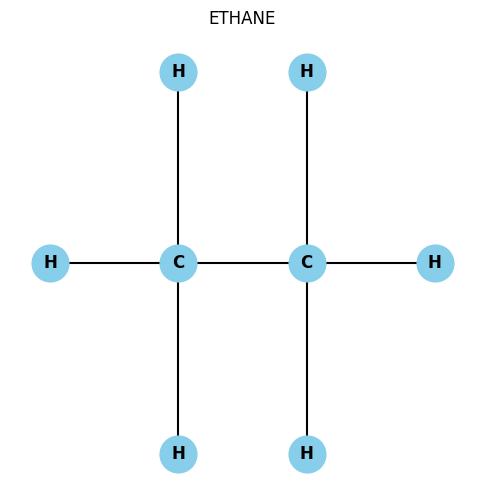

MI for hexane: 40.90909090909091


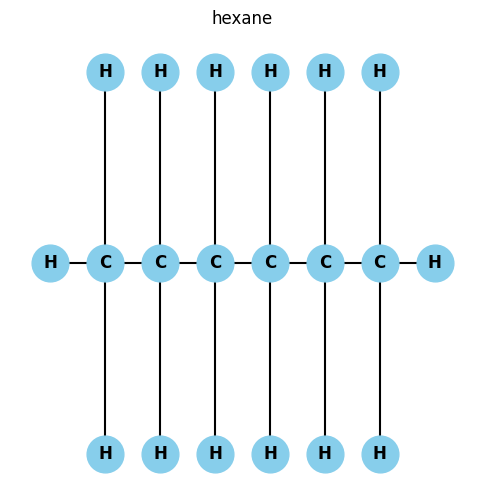

MI for Alaline: 40.90909090909091


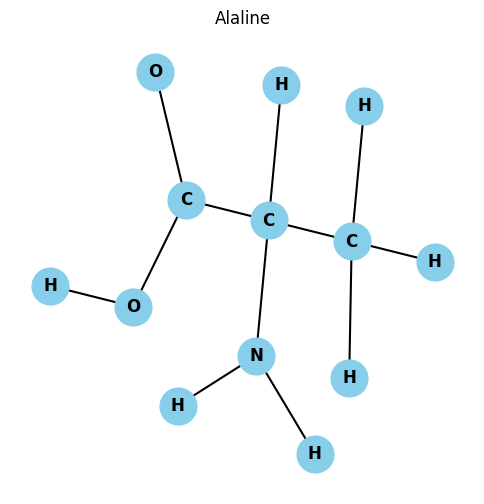

MI for Arginine: 378.78260869565213


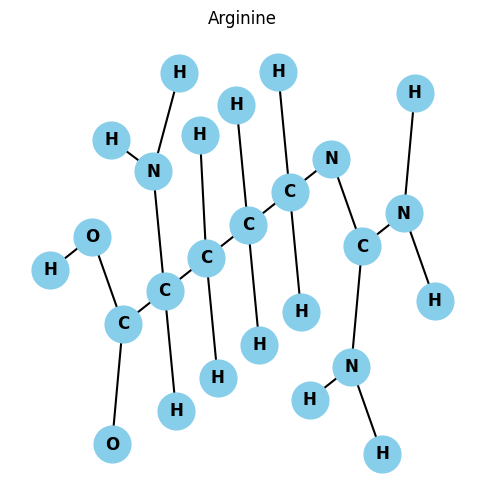

MI of A: 40.90909090909091


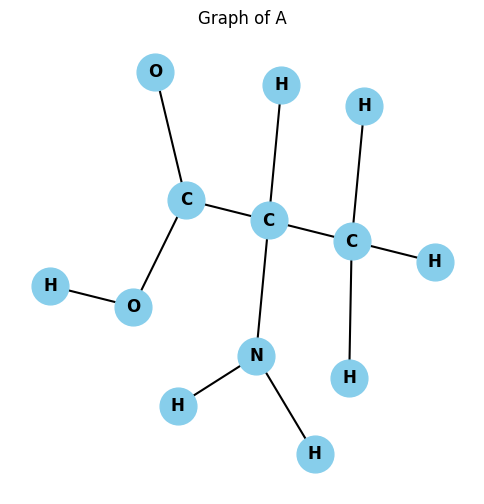

MI of R: 378.78260869565213


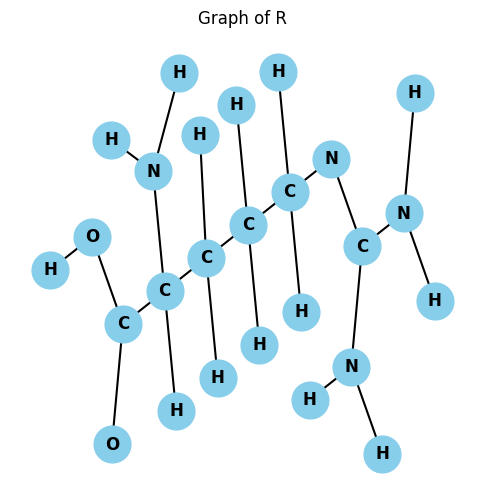

MI of N: 152.47058823529412


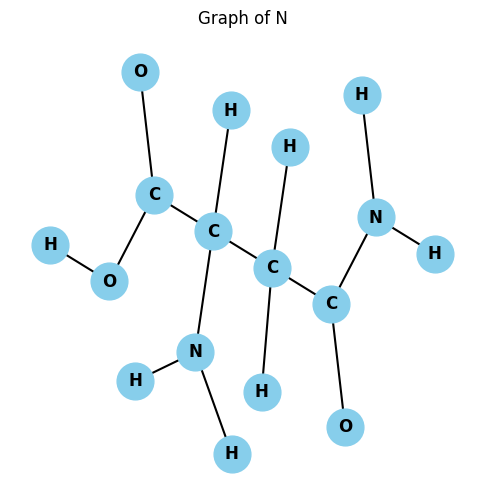

MI of D: 152.47058823529412


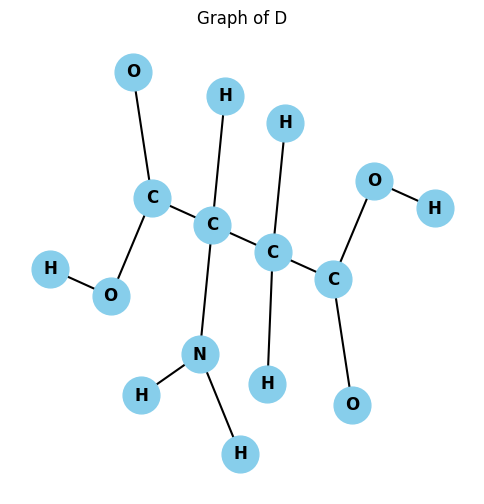

MI of C: 67.84615384615385


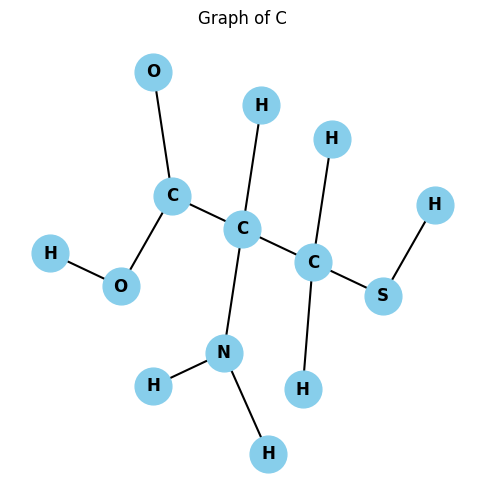

MI of Q: 213.15789473684208


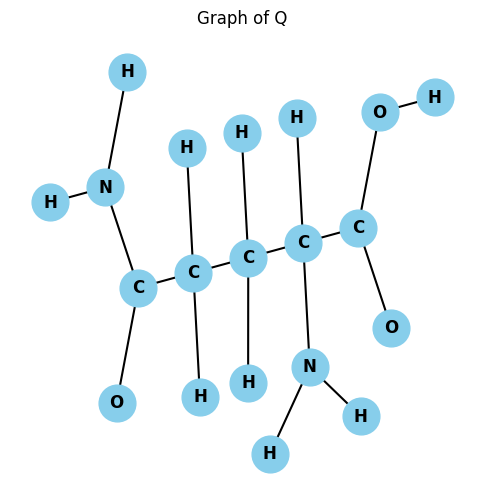

MI of E: 213.15789473684208


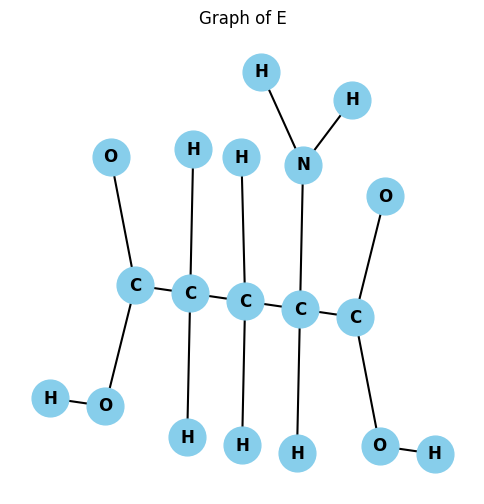

MI of G: 22.22222222222222


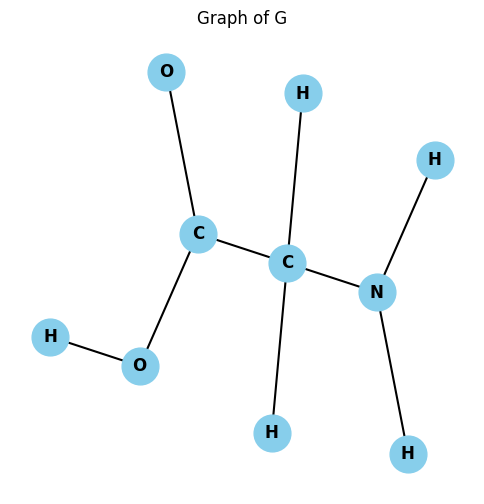

MI of H: 423.5


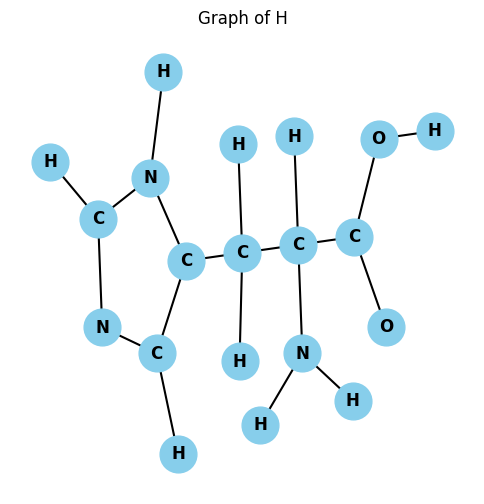

MI of I: 152.47058823529412


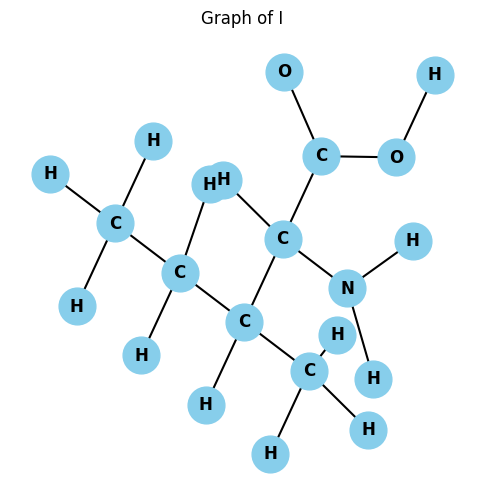

MI of L: 152.47058823529412


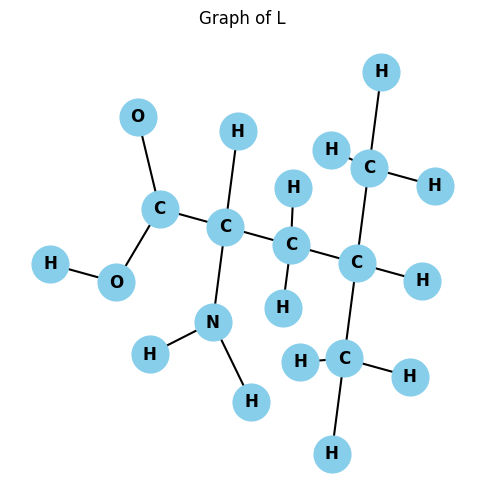

MI of K: 213.15789473684208


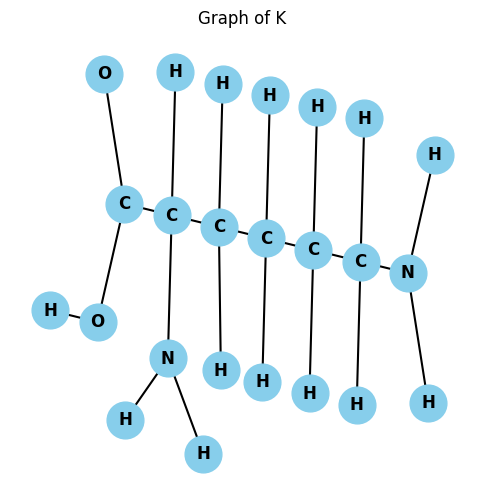

MI of M: 152.47058823529412


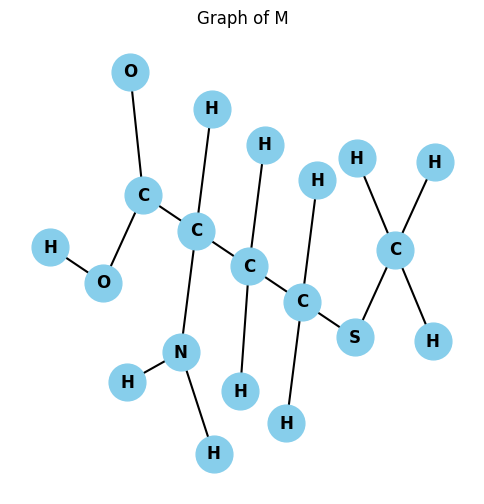

MI of F: 594.0


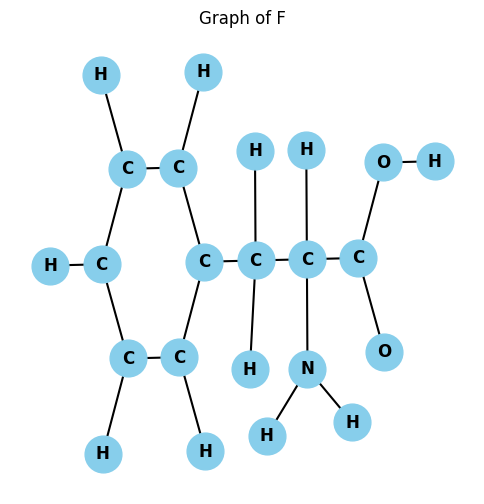

MI of P: 160.0


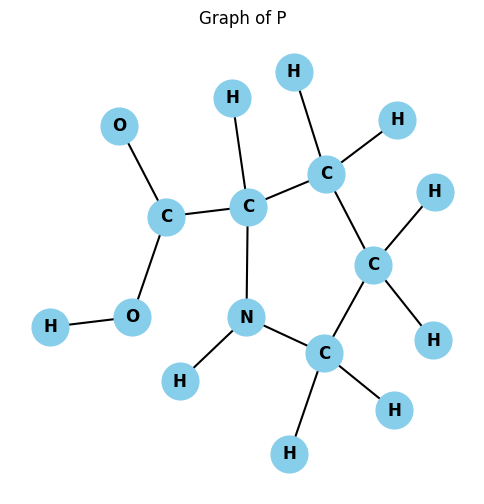

MI of S: 67.84615384615385


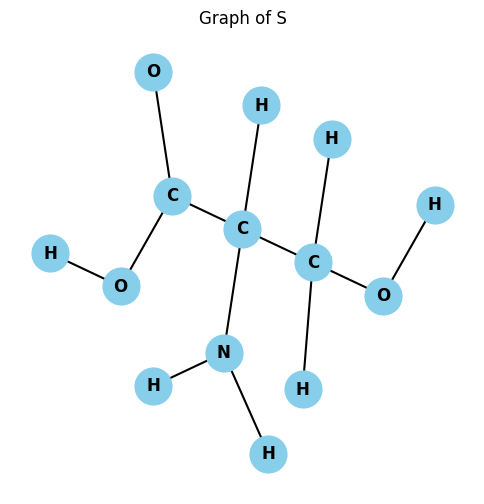

MI of T: 104.53333333333333


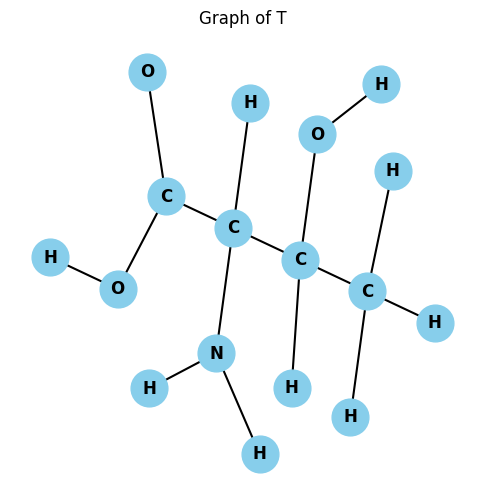

MI of W: 1950.967741935484


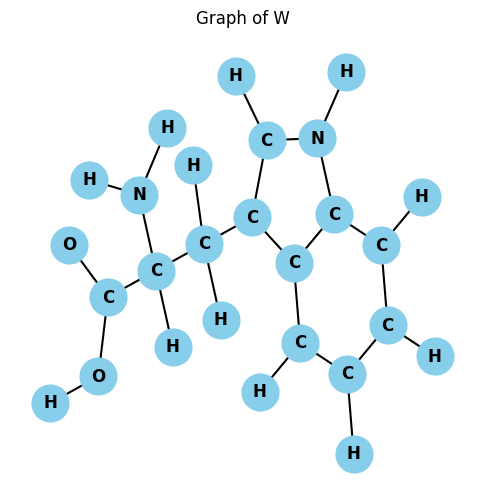

MI of Y: 845.0


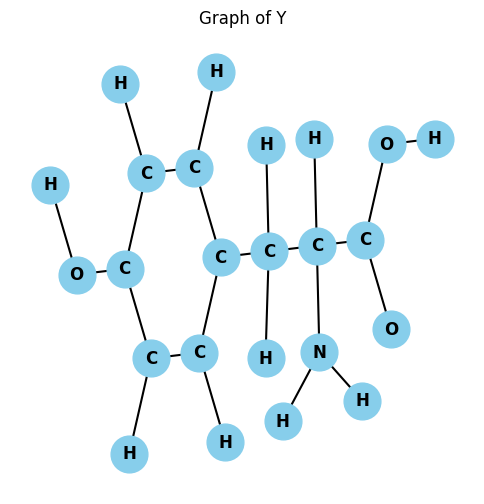

MI of V: 104.53333333333333


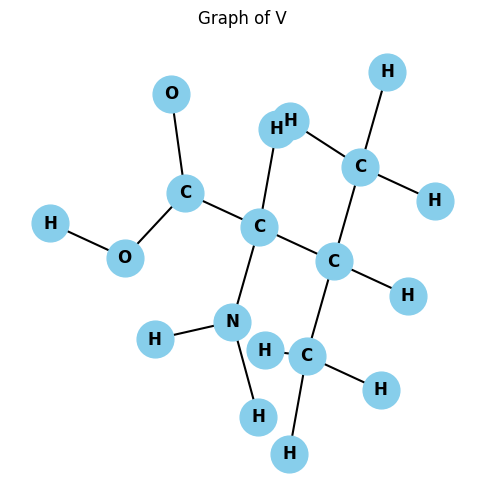

In [ ]:
# MI indice
bioticMolecules_miMetrics = {}

#control01: ETHANE
parameters = process_smiles(abiotic_molecules['alkanes']['ethane'], "ETHANE")
G_ETHANE = nx.from_numpy_array(parameters['adj_matrix'])
V_ETHANE = parameters['V']
E_ETHANE = parameters['E']
#sum_pL_ETHANE = count_paths(G_ETHANE)
mi_alanine = ((V_ETHANE **2) * ((V_ETHANE - 1)**2)) / ((4 * V_ETHANE) - 2)
print("MI for ETHANE:", mi_alanine)
plot_molecular_graph(abiotic_molecules['alkanes']['ethane'], title="ETHANE")


#control02: HEXANE
parameters = process_smiles(abiotic_molecules['alkanes']['hexane'], "hexane")
G_HEXANE = nx.from_numpy_array(parameters['adj_matrix'])
V_HEXANE = parameters['V']
E_HEXANE = parameters['E']
#sum_pL_HEXANE = count_paths(G_HEXANE)
mi_alanine = ((V_HEXANE **2) * ((V_HEXANE - 1)**2)) / ((4 * V_HEXANE) - 2)
print("MI for hexane:", mi_alanine)
plot_molecular_graph(abiotic_molecules['alkanes']['hexane'], title="hexane")


#Alanine
parameters = process_smiles(aasmiles['A'], "Alanine")
G_alaline = nx.from_numpy_array(parameters['adj_matrix'])
V_alaline = parameters['V']
E_alaline = parameters['E']
max_L_alanine = int(np.max(parameters["distance_matrix"]))
sum_pL_alaline = count_paths(G_alaline, max_L_alanine)
mi_alanine = ((V_alaline * E_alaline) / (V_alaline + E_alaline)) * sum_pL_alaline
print("MI for Alaline:", mi_alanine)
plot_molecular_graph(aasmiles['A'], title="Alaline")

#Arginine
parameters = process_smiles(aasmiles['R'], "Arginine")
G_arginine = nx.from_numpy_array(parameters['adj_matrix'])
V_arginine = parameters['V']
E_arginine = parameters['E']
max_L_arginine = int(np.max(parameters["distance_matrix"]))
sum_pL_arginine = count_paths(G_arginine, max_L_arginine)
mi_arginine = ((V_arginine * E_arginine) / (V_arginine + E_arginine)) * sum_pL_arginine
print("MI for Arginine:", mi_arginine)
plot_molecular_graph(aasmiles['R'], title="Arginine")

for aa, smiles in aasmiles.items():
    parameters = process_smiles(smiles, aa)

    G = nx.from_numpy_array(parameters['adj_matrix'])
    V = parameters['V']
    E = parameters['E']
    max_L = int(np.max(parameters["distance_matrix"]))
    sum_pL = count_paths(G, max_L)

    MI_val = ((V * E) / (V + E)) * sum_pL
    bioticMolecules_miMetrics[aa] = (MI_val)
    print(f"MI of {aa}: {MI_val}")
    plot_molecular_graph(aasmiles[aa], title=f"Graph of {aa}")


MI of A: 40.90909090909091


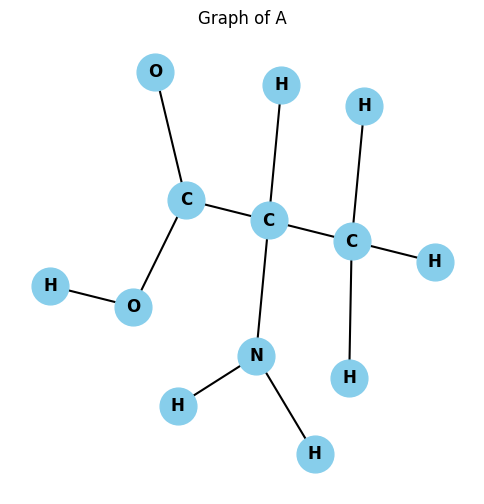

MI of R: 378.78260869565213


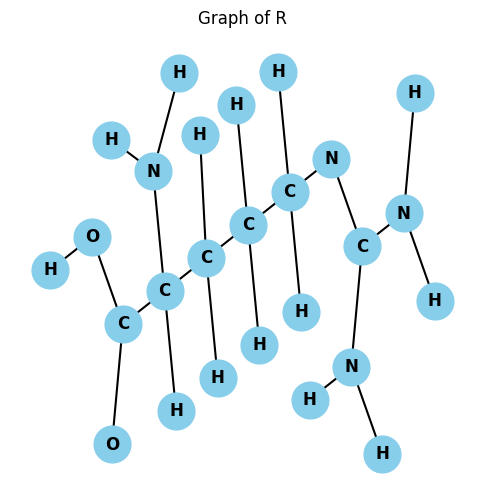

MI of N: 152.47058823529412


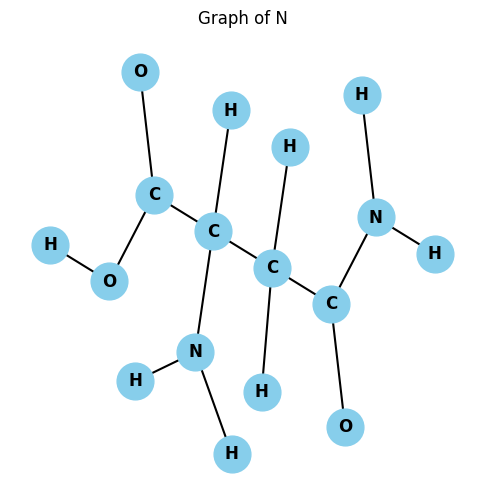

MI of D: 152.47058823529412


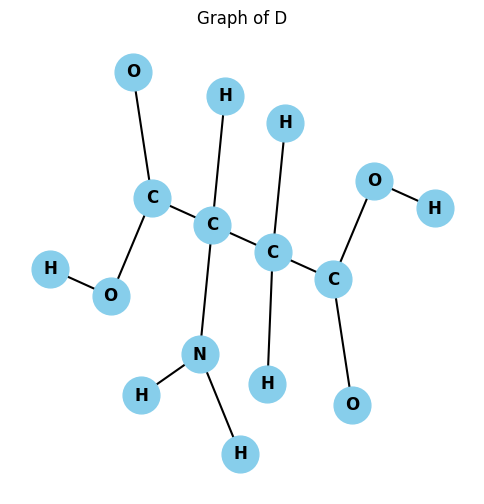

MI of C: 67.84615384615385


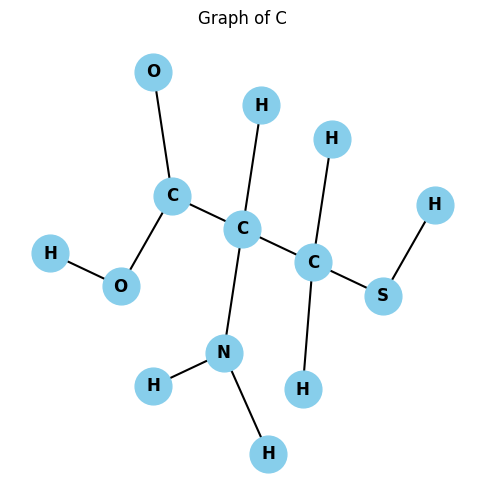

MI of Q: 213.15789473684208


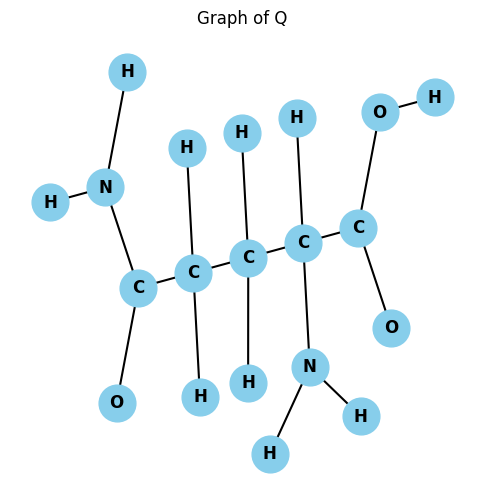

MI of E: 213.15789473684208


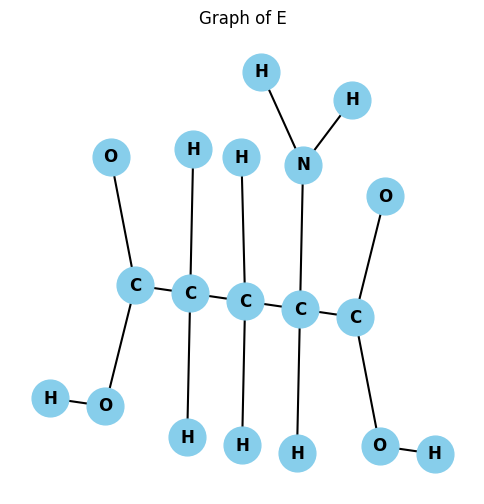

MI of G: 22.22222222222222


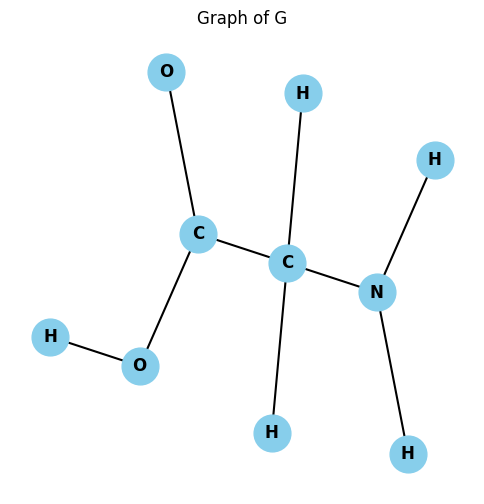

MI of H: 423.5


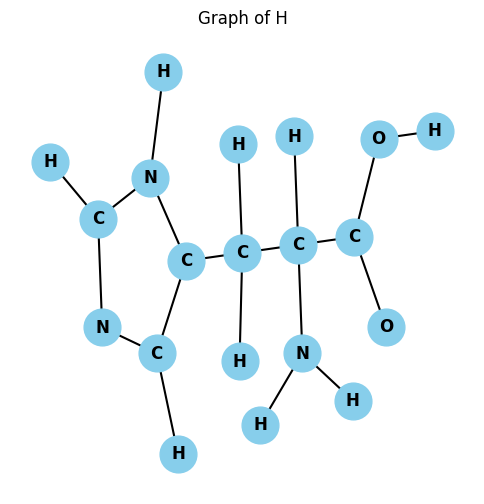

MI of I: 152.47058823529412


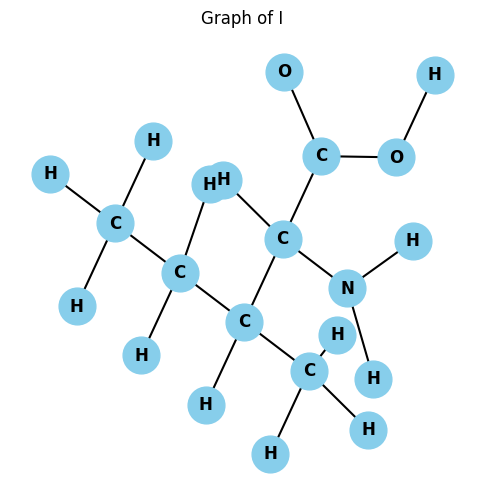

MI of L: 152.47058823529412


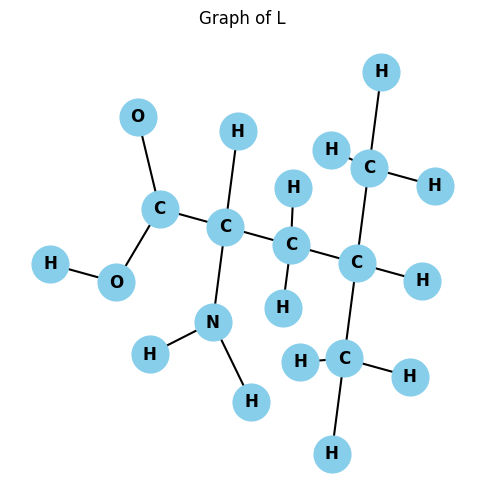

MI of K: 213.15789473684208


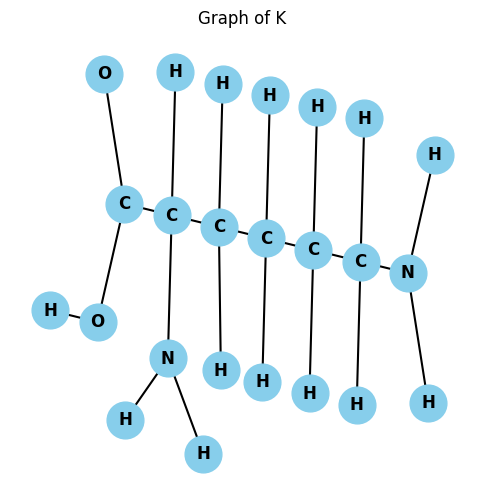

MI of M: 152.47058823529412


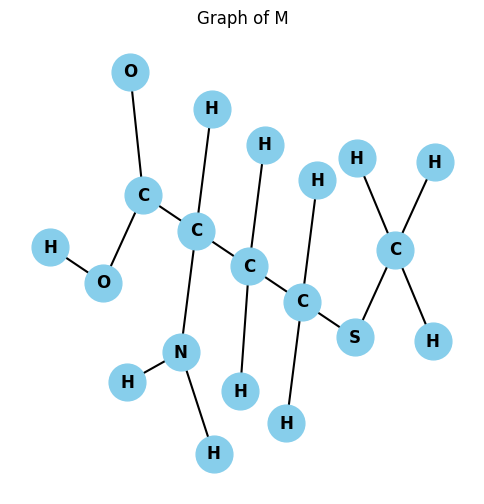

MI of F: 594.0


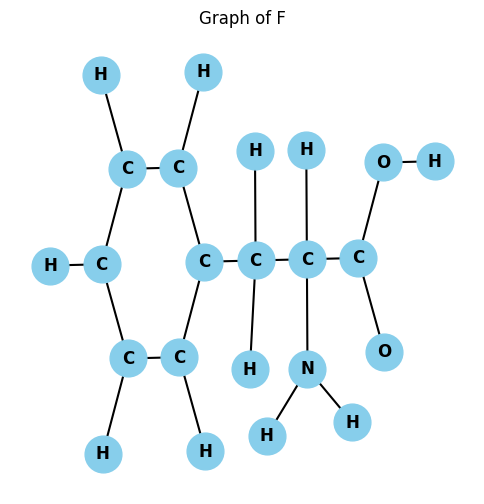

MI of P: 160.0


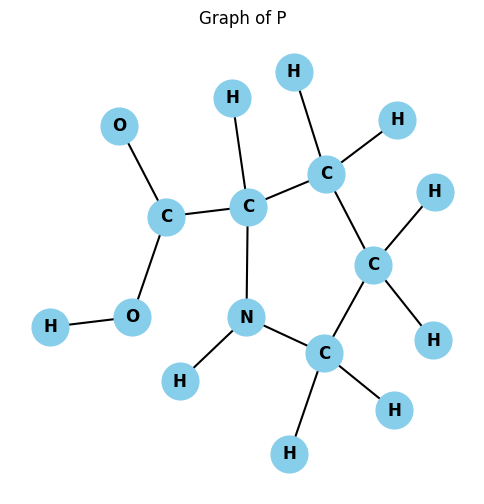

MI of S: 67.84615384615385


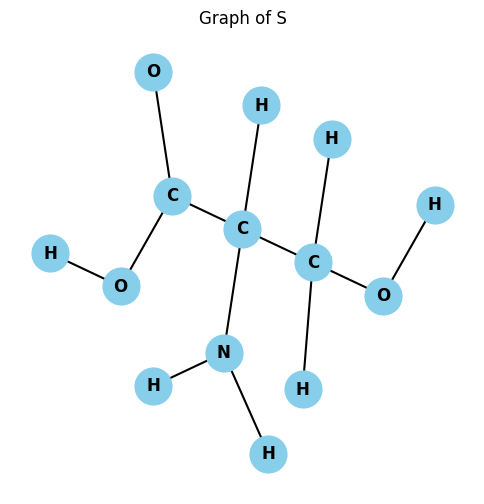

MI of T: 104.53333333333333


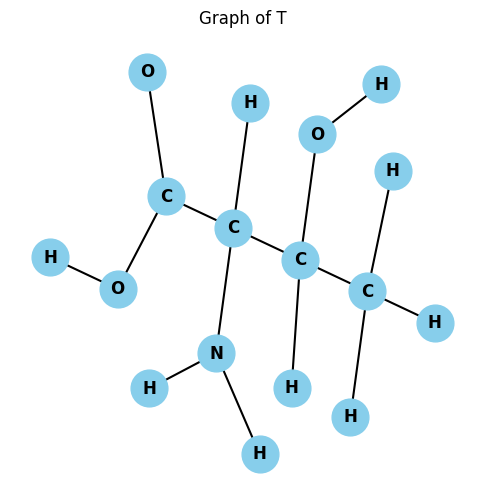

MI of W: 1950.967741935484


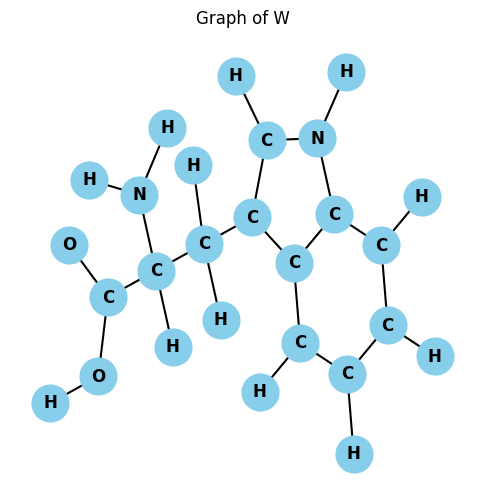

MI of Y: 845.0


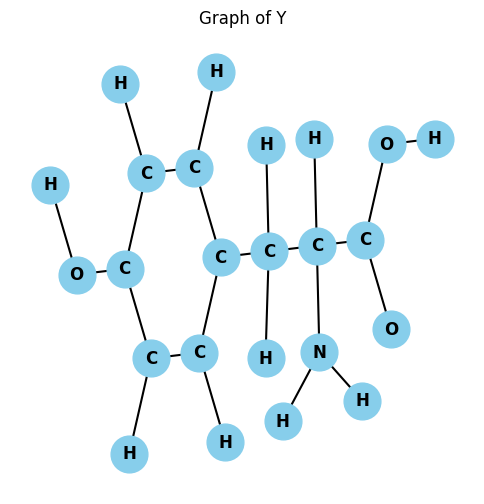

MI of V: 104.53333333333333


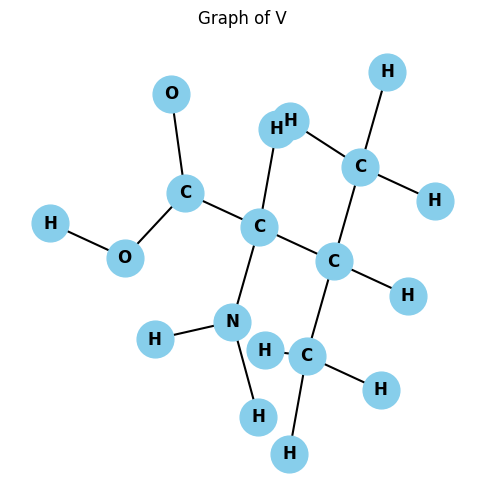

In [ ]:
for aa, smiles in aasmiles.items():
    parameters = process_smiles(smiles, aa)

    G = nx.from_numpy_array(parameters['adj_matrix'])
    V = parameters['V']
    E = parameters['E']
    max_L = int(np.max(parameters["distance_matrix"]))
    sum_pL = count_paths(G, max_length=max_L)

    MI_val = ((V * E) / (V + E)) * sum_pL
    bioticMolecules_miMetrics[aa] = (MI_val)
    print(f"MI of {aa}: {MI_val}")
    plot_molecular_graph(aasmiles[aa], title=f"Graph of {aa}")


In [ ]:
bioticMolecules_miMetrics

{'A': 40.90909090909091,
 'R': 378.78260869565213,
 'N': 152.47058823529412,
 'D': 152.47058823529412,
 'C': 67.84615384615385,
 'Q': 213.15789473684208,
 'E': 213.15789473684208,
 'G': 22.22222222222222,
 'H': 423.5,
 'I': 152.47058823529412,
 'L': 152.47058823529412,
 'K': 213.15789473684208,
 'M': 152.47058823529412,
 'F': 594.0,
 'P': 160.0,
 'S': 67.84615384615385,
 'T': 104.53333333333333,
 'W': 1950.967741935484,
 'Y': 845.0,
 'V': 104.53333333333333}

## MB indice

In [ ]:
#MB index (variant of Minoli index)

#definition of a new function to calculate the total lenght of all paths in G
def total_path_length(graph, max_length):
    total = 0

    #for each different atom pair
    for i in graph.nodes():
        for j in graph.nodes():
            if i < j:  #avoiding count twice (j,i) and (i,j)
                #getting all the simple paths from i to j with the maximium max_length of bonds
                paths = nx.all_simple_paths(graph, source=i, target=j, cutoff=max_length)

                for path in paths:
                    #number of bonds in the path
                    caminho = len(path) - 1
                    total += caminho

    return total


MB for ETHANE: 0.6666666666666666


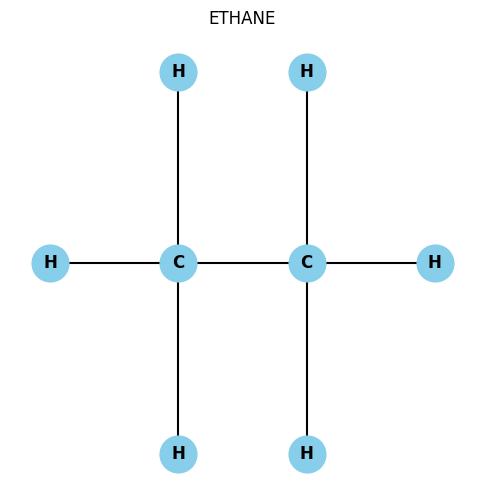

MB for HEXANE: 95.45454545454545


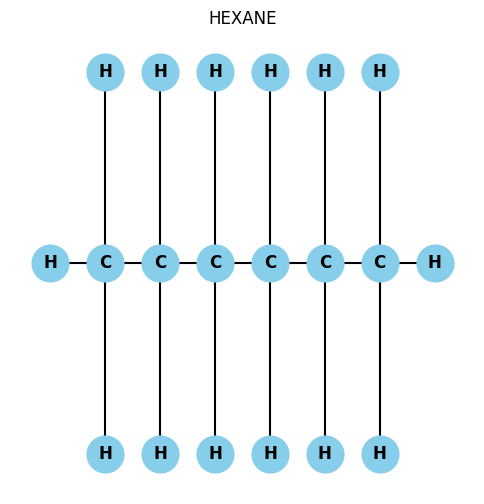

In [ ]:
#control01: ETHANE
parameters_mb = process_smiles(abiotic_molecules['alkanes']['ethane'], "ETHANE")
G_ETHANE = nx.from_numpy_array(parameters_mb['adj_matrix'])
V_ETHANE = parameters_mb['V']
E_ETHANE = parameters_mb['E']

max_L_ethane = int(np.max(parameters_mb["distance_matrix"]))
sum_pL_ethane = total_path_length(G_ETHANE, max_L_ethane)
mb__ethane = ((V_ETHANE * E_ETHANE) / (V_ETHANE + E_ETHANE)) * sum_pL_ethane
print("MB for ETHANE:", mb__ethane)
plot_molecular_graph(abiotic_molecules['alkanes']['ethane'], title="ETHANE")


parameters_mb = process_smiles(abiotic_molecules['alkanes']['hexane'], "hexane")
G_ETHANE = nx.from_numpy_array(parameters_mb['adj_matrix'])
V_ETHANE = parameters_mb['V']
E_ETHANE = parameters_mb['E']

max_L_ethane = int(np.max(parameters_mb["distance_matrix"]))
sum_pL_ethane = total_path_length(G_ETHANE, max_L_ethane)
mb__ethane = ((V_ETHANE * E_ETHANE) / (V_ETHANE + E_ETHANE)) * sum_pL_ethane
print("MB for HEXANE:", mb__ethane)
plot_molecular_graph(abiotic_molecules['alkanes']['hexane'], title="HEXANE")


# Comparing metrics

## Table of analysed molecules and its metrics value

This table consolidates all raw metric values computed for each molecule.

In [ ]:
import pandas as pd
from tabulate import tabulate

metric_dicts = {
    "BHI": bioticMolecules_bhiMetrics | abioticMolecules_bhiMetrics,
    "BAL": bioticMolecules_balMetrics | abioticMolecules_balMetrics,
    "WCX": bioticMolecules_wcxMetrics | abioticMolecules_wcxMetrics,
    "PF_CM": bioticMolecules_pfMetrics | abioticMolecules_pfMetrics,
    "FCC": bioticMolecules_fccMetrics | abioticMolecules_fccMetrics,
    "SPS": {**{k: v["SPS"] for k, v in bioticMolecules_snSPSMetrics.items()},
            **{k: v["SPS"] for k, v in abioticMolecules_snSPSMetrics.items()}},
    "nSPS": {**{k: v["nSPS"] for k, v in bioticMolecules_snSPSMetrics.items()},
             **{k: v["nSPS"] for k, v in abioticMolecules_snSPSMetrics.items()}},
    "BS": bioticMolecules_bsMetrics | abioticMolecules_bsMetrics,
    "BAR": bioticMolecules_baroneMetrics | abioticMolecules_baroneMetrics,
    "FSP3": bioticMolecules_fsp3Metrics | abioticMolecules_fsp3Metrics,
    "WH": bioticMolecules_whMetrics | abioticMolecules_whMetrics,
    "SMCM": bioticMolecules_smcmMetrics | abioticMolecules_smcmMetrics,
    "KAPPA": bioticMolecules_kappaMetrics | abioticMolecules_kappaMetrics,
    "SMM1": bioticMolecules_smm1Metrics | abioticMolecules_smm1Metrics,
    "SMM2": bioticMolecules_smm2Metrics | abioticMolecules_smm2Metrics,
    "MGC": abioticMolecules_mgcMetrics | bioticMolecules_mgcMetrics
}

metric_descriptions = {
    "BHI": "PubChem complexity score based on atoms and bonds",
    "BAL": "Balaban's J topological complexity index",
    "WCX": "Symmetric walk count (lower = more symmetric)",
    "PF_CM": "Proudfoot CM metric (chemical environment diversity)",
    "FCC": "Fraction of chiral carbon atoms",
    "SPS": "Spacial Score (3D complexity total)",
    "nSPS": "Normalized Spacial Score (per heavy atom)",
    "BS": "Böttcher score (3D complexity using hybrid & stereo)",
    "BAR": "Barone index (valence + ring/heteroatom complexity)",
    "FSP3": "Fraction of sp³-hybridized carbon atoms",
    "WH": "Weighted heteroatom count",
    "SMCM": "Small molecule complexity metric",
    "KAPPA": "Molecular shape indices (Kappa1–3)",
    "SMM1": "Synthetic molecular measure 1 (substructure frequency)",
    "SMM2": "Synthetic molecular measure 2 (complexity per atom)"
}

all_molecules = set()
for d in metric_dicts.values():
    all_molecules.update(d.keys())

data = {mol: {} for mol in all_molecules}

for metric, d in metric_dicts.items():
    for mol, val in d.items():
        data[mol][metric] = val

df_metrics = pd.DataFrame.from_dict(data, orient='index')

df_metrics.reset_index(inplace=True)
df_metrics.rename(columns={'index': 'Molecule'}, inplace=True)

biotic_set = set(bioticMolecules_bhiMetrics.keys())  # exemplo base para biotic
df_metrics['Type'] = df_metrics['Molecule'].apply(lambda x: 'Biotic' if x in biotic_set else 'Abiotic')

df_metrics['HeavyAtoms'] = (df_metrics['SPS'] / df_metrics['nSPS']).round(1)

cols_order = ['Molecule', 'Type', 'HeavyAtoms'] + list(metric_dicts.keys())
df_metrics = df_metrics[cols_order]
df_metrics.fillna("-", inplace=True)

print("Table of molecule metrics used:\n")
print(tabulate(df_metrics, headers='keys', tablefmt='fancy_grid', showindex=False))

desc_df = pd.DataFrame.from_dict(metric_descriptions, orient='index', columns=['Description'])
print("\nMetric descriptions:\n")
print(tabulate(desc_df, headers='keys', tablefmt='fancy_grid'))

df_metrics.to_csv('completed_moleculasmetrics.csv', index=False)
# df_metrics.to_excel('metricas_moleculares_completas.xlsx', index=False)



Table of molecule metrics used:

╒═══════════════════════════════╤═════════╤══════════════╤═══════╤═════════╤══════════════════╤══════════╤═══════════╤═══════╤══════════╤══════════╤═══════╤══════════╤══════╤════════╤═══════════════════════════════════════════════════════════════════════════════════════════╤════════╤════════╤═══════╕
│ Molecule                      │ Type    │ HeavyAtoms   │   BHI │     BAL │              WCX │    PF_CM │       FCC │   SPS │     nSPS │       BS │   BAR │     FSP3 │   WH │   SMCM │ KAPPA                                                                                     │   SMM1 │   SMM2 │   MGC │
╞═══════════════════════════════╪═════════╪══════════════╪═══════╪═════════╪══════════════════╪══════════╪═══════════╪═══════╪══════════╪══════════╪═══════╪══════════╪══════╪════════╪═══════════════════════════════════════════════════════════════════════════════════════════╪════════╪════════╪═══════╡
│ D                             │ Biotic  │ 9.0          │ 13

/tmp/ipython-input-26-2146898647.py:65: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_metrics.fillna("-", inplace=True)


## Molecular Metric Table Grouped by Class

Abiotic molecules are grouped by class. The best Kappa shape index is also calculated to reflect structural variation.


In [ ]:
import pandas as pd

metric_dicts = {
    "BHI": bioticMolecules_bhiMetrics | abioticMolecules_bhiMetrics,
    "BAL": bioticMolecules_balMetrics | abioticMolecules_balMetrics,
    "WCX": bioticMolecules_wcxMetrics | abioticMolecules_wcxMetrics,
    "PF_CM": bioticMolecules_pfMetrics | abioticMolecules_pfMetrics,
    "FCC": bioticMolecules_fccMetrics | abioticMolecules_fccMetrics,
    "SPS": {**{k: v["SPS"] for k, v in bioticMolecules_snSPSMetrics.items()},
            **{k: v["SPS"] for k, v in abioticMolecules_snSPSMetrics.items()}},
    "nSPS": {**{k: v["nSPS"] for k, v in bioticMolecules_snSPSMetrics.items()},
             **{k: v["nSPS"] for k, v in abioticMolecules_snSPSMetrics.items()}},
    "BS": bioticMolecules_bsMetrics | abioticMolecules_bsMetrics,
    "BAR": bioticMolecules_baroneMetrics | abioticMolecules_baroneMetrics,
    "FSP3": bioticMolecules_fsp3Metrics | abioticMolecules_fsp3Metrics,
    "WH": bioticMolecules_whMetrics | abioticMolecules_whMetrics,
    "SMCM": bioticMolecules_smcmMetrics | abioticMolecules_smcmMetrics,
    "KAPPA": bioticMolecules_kappaMetrics | abioticMolecules_kappaMetrics,
    "SMM1": bioticMolecules_smm1Metrics | abioticMolecules_smm1Metrics,
    "SMM2": bioticMolecules_smm2Metrics | abioticMolecules_smm2Metrics,
    "MGC": abioticMolecules_mgcMetrics | bioticMolecules_mgcMetrics
}

all_keys = set().union(*[d.keys() for d in metric_dicts.values()])
data = {key: {} for key in all_keys}

for metric, d in metric_dicts.items():
    for mol, value in d.items():
        data[mol][metric] = value

df_metrics = pd.DataFrame.from_dict(data, orient="index")
df_metrics.reset_index(inplace=True)
df_metrics.rename(columns={"index": "Molecule"}, inplace=True)

df_metrics["Type"] = df_metrics["Molecule"].apply(
    lambda x: "Biotic" if x in bioticMolecules_bhiMetrics else "Abiotic"
)

def split_class(mol_name):
    if "|" in mol_name:
        class_, name = [s.strip() for s in mol_name.split("|", 1)]
        return pd.Series([name, class_])
    else:
        return pd.Series([mol_name, None])

df_metrics[["Molecule", "Class"]] = df_metrics["Molecule"].apply(split_class)

df_metrics["HeavyAtoms"] = (df_metrics["SPS"] / df_metrics["nSPS"]).round(1)

def best_kappa(kappa_dict):
    if isinstance(kappa_dict, dict):
        return max(kappa_dict.values())
    else:
        return None

df_metrics["Best_Kappa"] = df_metrics["KAPPA"].apply(best_kappa)

cols = df_metrics.columns.tolist()
ordered_cols = ["Molecule", "Class", "Type", "HeavyAtoms", "Best_Kappa"] + \
               [c for c in cols if c not in ["Molecule", "Class", "Type", "HeavyAtoms", "Best_Kappa"]]

df_metrics = df_metrics[ordered_cols]

from tabulate import tabulate
print("Tabela de Métricas Moleculares:\n")
print(tabulate(df_metrics, headers="keys", tablefmt="fancy_grid", showindex=False))


Tabela de Métricas Moleculares:

╒════════════════════╤════════════════╤═════════╤══════════════╤══════════════╤═══════╤═════════╤══════════════════╤══════════╤═══════════╤═══════╤══════════╤══════════╤═══════╤══════════╤══════╤════════╤═══════════════════════════════════════════════════════════════════════════════════════════╤════════╤════════╤═══════╕
│ Molecule           │ Class          │ Type    │   HeavyAtoms │   Best_Kappa │   BHI │     BAL │              WCX │    PF_CM │       FCC │   SPS │     nSPS │       BS │   BAR │     FSP3 │   WH │   SMCM │ KAPPA                                                                                     │   SMM1 │   SMM2 │   MGC │
╞════════════════════╪════════════════╪═════════╪══════════════╪══════════════╪═══════╪═════════╪══════════════════╪══════════╪═══════════╪═══════╪══════════╪══════════╪═══════╪══════════╪══════╪════════╪═══════════════════════════════════════════════════════════════════════════════════════════╪════════╪════════╪═══════

## Total Complexity Index and Classification by Molecule Type

This analysis combines all graph and information theory metrics, computes normalized averages, and interprets each molecule’s structural features based on individual metric behaviors.

In [ ]:
# calculate a meaning according to metrics value results

from sklearn.preprocessing import MinMaxScaler
import numpy as np

df_metrics["NSMM"] = np.sqrt(df_metrics["SMM1"]**2 + df_metrics["SMM2"]**2)
df_metrics["NK"] = df_metrics["KAPPA"].apply(
    lambda d: np.linalg.norm(list(d.values())) if isinstance(d, dict) else np.nan
)

# selecting just the graph indexes
graph_cols = ["BHI", "BAL", "WCX", "PF_CM", "NSMM", "NK"]

scaler = MinMaxScaler()
normalized_graph = scaler.fit_transform(df_metrics[graph_cols])

df_metrics["GraphComplexityIndex"] = normalized_graph.mean(axis=1).round(3)


def interpret_graph_metrics(row):
    parts = []

    # BHI
    bhi = row["BHI"]
    if bhi < 80:
        parts.append("\n simple structure with low branching and atomic diversity (low BHI)")
    elif bhi > 180:
        parts.append("\n highly branched structure with diverse heteroatoms (high BHI)")

    # BAL
    bal = row["BAL"]
    if bal < 1.7:
        parts.append("\n linear or slightly branched structure (low BAL)")
    elif bal > 3.3:
        parts.append("\n highly branched structure with varied paths (high BAL)")

    # WCX
    wcx = row["WCX"]
    if wcx < 100:
        parts.append("\n low path redundancy across the molecular graph (low WCX)")
    elif wcx > 700:
        parts.append("\n many possible paths within the molecule (high WCX)")

    # PF_CM
    pf = row["PF_CM"]
    if pf < 10:
        parts.append("\n locally simple atomic connectivity (low PF_CM)")
    elif pf > 30:
        parts.append("\n diverse atomic connectivity and microenvironments (high PF_CM)")

    # NSMM
    nsmm = row["NSMM"]
    if nsmm > 10:
        parts.append("\n asymmetric or branched topology (high NSMM)")

    # NK
    nk = row["NK"]
    if nk > 10:
        parts.append("\n complex molecular shape far from linearity (high NK)")

    # FCC
    fcc = row["FCC"]
    if fcc < 0.1:
        parts.append("\n low or absent central chirality (low FCC)")
    elif fcc > 0.3:
        parts.append("\n significant presence of chiral centers in the molecular core (high FCC)")

    # SPS
    sps = row["SPS"]
    if sps < 10:
        parts.append("\n low spatial bulk and stereochemical richness (low SPS)")
    elif sps > 30:
        parts.append("\n voluminous and stereochemically rich 3D structure (high SPS)")

    # nSPS
    nsps = row["nSPS"]
    if nsps < 0.8:
        parts.append("\n low 3D complexity density per atom (low nSPS)")
    elif nsps > 1.5:
        parts.append("\n high spatial complexity per heavy atom (high nSPS)")

    # BAR
    bar = row["BAR"]
    if bar < 5:
        parts.append("\n structurally simple and chemically homogeneous (low BAR)")
    elif bar > 15:
        parts.append("\n structurally rich with multiple rings, bonds, and atomic types (high BAR)")

    # FSP3
    fsp3 = row["FSP3"]
    if fsp3 < 0.3:
        parts.append("\n planar and unsaturated structure dominated by sp2 carbons (low FSP3)")
    elif fsp3 > 0.6:
        parts.append("\n highly saturated structure with complex 3D features (high FSP3)")

    # WH
    wh = row["WH"]
    if wh < 2:
        parts.append("\n simple scaffold with few rings or stereocenters (low WH)")
    elif wh > 6:
        parts.append("\n rigid and stereochemically complex 3D structure (high WH)")

    # SMCM
    smcm = row["SMCM"]
    if smcm < 4:
        parts.append("\n chemically simple with low local complexity (low SMCM)")
    elif smcm > 10:
        parts.append("\n chemically rich and topologically intricate structure (high SMCM)")

    if not parts:
        return "overall simple structure with low connectivity and diversity"
    return "; ".join(parts)


#now informational index
info_cols = ["FCC", "SPS", "nSPS", "BAR", "FSP3", "WH", "SMCM"]
normalized_info = scaler.fit_transform(df_metrics[info_cols])
df_metrics["InfoTheoryComplexityIndex"] = normalized_info.mean(axis=1).round(3)

df_metrics["GraphMetrics Interpretation"] = df_metrics.apply(interpret_graph_metrics, axis=1)

df_metrics["TotalComplexityIndex"] = df_metrics[["GraphComplexityIndex", "InfoTheoryComplexityIndex"]].mean(axis=1).round(3)
print("Table of Molecular metrics:\n")
print(tabulate(df_metrics, headers="keys", tablefmt="fancy_grid", showindex=False))

from tabulate import tabulate

# biolgical molecules only
df_biotic = df_metrics[df_metrics["Type"] == "Biotic"].sort_values("TotalComplexityIndex", ascending=False)
print("\nTable --> Biotic Molecules:")
print(tabulate(df_biotic, headers="keys", tablefmt="fancy_grid", showindex=False))

# abiotic molecule onlyy
df_abiotic = df_metrics[df_metrics["Type"] == "Abiotic"].sort_values("TotalComplexityIndex", ascending=False)
classes = df_abiotic["Class"].dropna().unique()
print("\nTable --> Abiotic Molecules:")
for cls in sorted(classes):
    df_cls = df_abiotic[df_abiotic["Class"] == cls].sort_values("TotalComplexityIndex", ascending=False)
    print(f"\nTable --> Abiotic Molecules of Class: {cls}")
    print(tabulate(df_cls, headers="keys", tablefmt="fancy_grid", showindex=False))




Table of Molecular metrics:

╒════════════════════╤════════════════╤═════════╤══════════════╤══════════════╤═══════╤═════════╤══════════════════╤══════════╤═══════════╤═══════╤══════════╤══════════╤═══════╤══════════╤══════╤════════╤═══════════════════════════════════════════════════════════════════════════════════════════╤════════╤════════╤═══════╤══════════╤══════════╤════════════════════════╤═════════════════════════════╤══════════════════════════════════════════════════════════════════════════════╤════════════════════════╤════════════════════════════╕
│ Molecule           │ Class          │ Type    │   HeavyAtoms │   Best_Kappa │   BHI │     BAL │              WCX │    PF_CM │       FCC │   SPS │     nSPS │       BS │   BAR │     FSP3 │   WH │   SMCM │ KAPPA                                                                                     │   SMM1 │   SMM2 │   MGC │     NSMM │       NK │   GraphComplexityIndex │   InfoTheoryComplexityIndex │ GraphMetrics Interpretation           

## Summary of all metric results classifying each molecule by complexity level

Based on the computed complexity scores, each molecule was classified as having low, intermediate, or high structural complexity.

In [ ]:
def interpret_complexity(score):
    if score >= 0.75:
        return "High structural complexity"
    elif score >= 0.5:
        return "Intermediate Complexity"
    elif score >= 0.25:
        return "Low complexity"
    else:
        return "Very simple"

df_metrics["ComplexityInterpretation"] = df_metrics["GraphComplexityIndex"].apply(interpret_complexity)

#biotic molecules
df_biotic = df_metrics[df_metrics["Type"] == "Biotic"].copy()
df_biotic = df_biotic.sort_values(by="GraphComplexityIndex", ascending=False)

print("\nBiological molecules order by complexity average\n")
print(tabulate(df_biotic[["Molecule", "GraphComplexityIndex", "InfoTheoryComplexityIndex", "ComplexityInterpretation"]], headers="keys", tablefmt="fancy_grid"))

# abiotic molecules
df_abiotic = df_metrics[df_metrics["Type"] == "Abiotic"].copy()
df_abiotic = df_abiotic.sort_values(by=["Class", "GraphComplexityIndex"], ascending=[True, False])

print("\nAbiotics Molecules by class\n")
print(tabulate(df_abiotic[["Molecule", "Class", "GraphComplexityIndex", "InfoTheoryComplexityIndex", "ComplexityInterpretation"]], headers="keys", tablefmt="fancy_grid"))

#all molecules together
print("\nAll by complexity index average\n")
print(tabulate(df_metrics[["Molecule", "Type", "GraphComplexityIndex", "ComplexityInterpretation", "InfoTheoryComplexityIndex"]], headers="keys", tablefmt="fancy_grid"))



Biological molecules order by complexity average

╒════╤════════════╤════════════════════════╤═════════════════════════════╤════════════════════════════╕
│    │ Molecule   │   GraphComplexityIndex │   InfoTheoryComplexityIndex │ ComplexityInterpretation   │
╞════╪════════════╪════════════════════════╪═════════════════════════════╪════════════════════════════╡
│ 38 │ W          │                  0.884 │                       0.587 │ High structural complexity │
├────┼────────────┼────────────────────────┼─────────────────────────────┼────────────────────────────┤
│ 29 │ R          │                  0.633 │                       0.587 │ Intermediate Complexity    │
├────┼────────────┼────────────────────────┼─────────────────────────────┼────────────────────────────┤
│  7 │ Y          │                  0.628 │                       0.512 │ Intermediate Complexity    │
├────┼────────────┼────────────────────────┼─────────────────────────────┼────────────────────────────┤
│ 34 │ F     

---
# Chemistry evolution analysis of aminoacids


In [ ]:
import pandas as pd

polar_classes = {
    "Nonpolar": ["A", "V", "L", "I", "M", "F", "W", "P", "G"],
    "Polar": ["S", "T", "N", "Q", "C", "Y"],
    "Acidic": ["D", "E"],
    "Basic": ["K", "R", "H"]
}

essential = {"H", "I", "L", "K", "M", "F", "T", "W", "V", "R"}  # R: conditionally essential

data = []
for code, smiles in aasmiles.items():
    for class_name, aa_list in polar_classes.items():
        if code in aa_list:
            polar_class = class_name
            break
    else:
        polar_class = "Unknown"

    is_essential = "Essential" if code in essential else "Non-essential"

    data.append({
        "Code": code,
        "SMILES": smiles,
        "Polarity": polar_class,
        "Essentiality": is_essential
    })

df_aa = pd.DataFrame(data)

from tabulate import tabulate
print(tabulate(df_aa, headers="keys", tablefmt="fancy_grid"))


╒════╤════════╤══════════════════════════════════╤════════════╤════════════════╕
│    │ Code   │ SMILES                           │ Polarity   │ Essentiality   │
╞════╪════════╪══════════════════════════════════╪════════════╪════════════════╡
│  0 │ A      │ CC(C(=O)O)N                      │ Nonpolar   │ Non-essential  │
├────┼────────┼──────────────────────────────────┼────────────┼────────────────┤
│  1 │ R      │ C(CC(C(=O)O)N)CN=C(N)N           │ Basic      │ Essential      │
├────┼────────┼──────────────────────────────────┼────────────┼────────────────┤
│  2 │ N      │ C(C(C(=O)O)N)C(=O)N              │ Polar      │ Non-essential  │
├────┼────────┼──────────────────────────────────┼────────────┼────────────────┤
│  3 │ D      │ C(C(C(=O)O)N)C(=O)O              │ Acidic     │ Non-essential  │
├────┼────────┼──────────────────────────────────┼────────────┼────────────────┤
│  4 │ C      │ C(C(C(=O)O)N)S                   │ Polar      │ Non-essential  │
├────┼────────┼─────────────

[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerator
[21:02:40] DEPRECATION WARNING: please use MorganGenerat

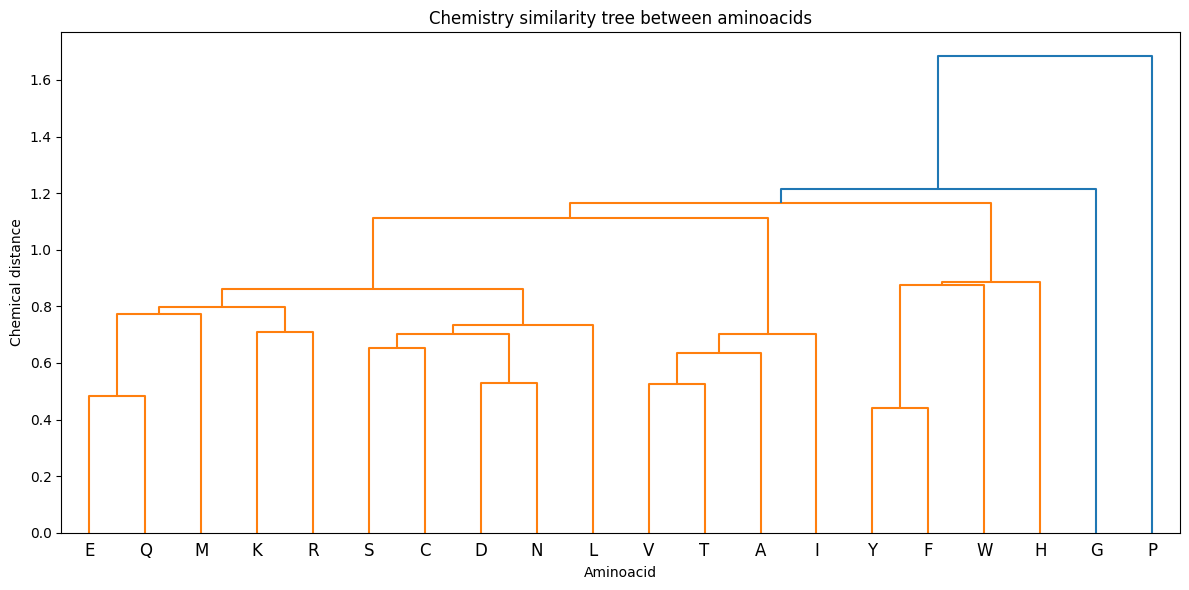

In [ ]:

from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np

# fingerprints
fps = []
labels = []
for aa, smi in aasmiles.items():
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    fps.append(fp)
    labels.append(aa)

# Distance matrix (Tanimoto similarityo)
n = len(fps)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = 1 - DataStructs.TanimotoSimilarity(fps[i], fps[j])

linked = linkage(sim_matrix, method='average')

plt.figure(figsize=(12, 6))
dendrogram(linked, labels=labels, orientation='top', distance_sort='descending')
plt.title("Chemistry similarity tree between aminoacids")
plt.xlabel("Aminoacid")
plt.ylabel("Chemical distance")
plt.tight_layout()
plt.show()


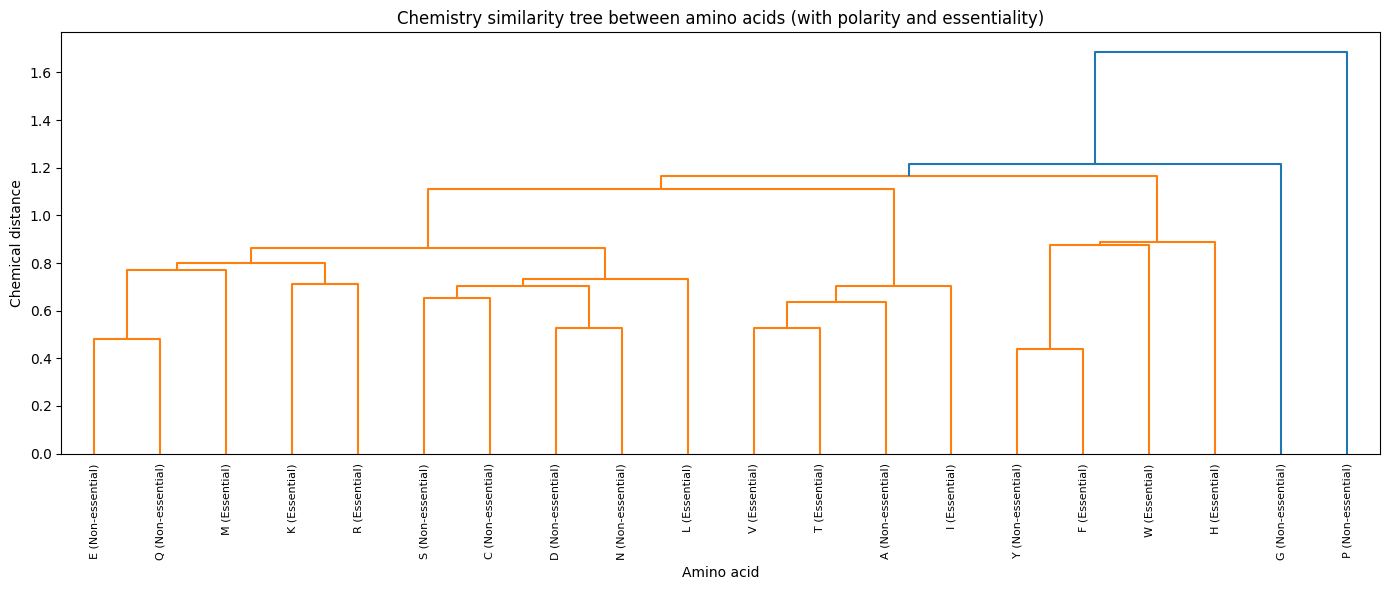

In [ ]:
modified_labels = [
    f"{aa} ({df_aa[df_aa['Code'] == aa]['Essentiality'].values[0]})"
    for aa in labels
]

plt.figure(figsize=(14, 6))
dendrogram(linked, labels=modified_labels, orientation='top', distance_sort='descending',
           leaf_rotation=90, leaf_font_size=8)
plt.title("Chemistry similarity tree between amino acids (with polarity and essentiality)")
plt.xlabel("Amino acid")
plt.ylabel("Chemical distance")
plt.tight_layout()
plt.show()

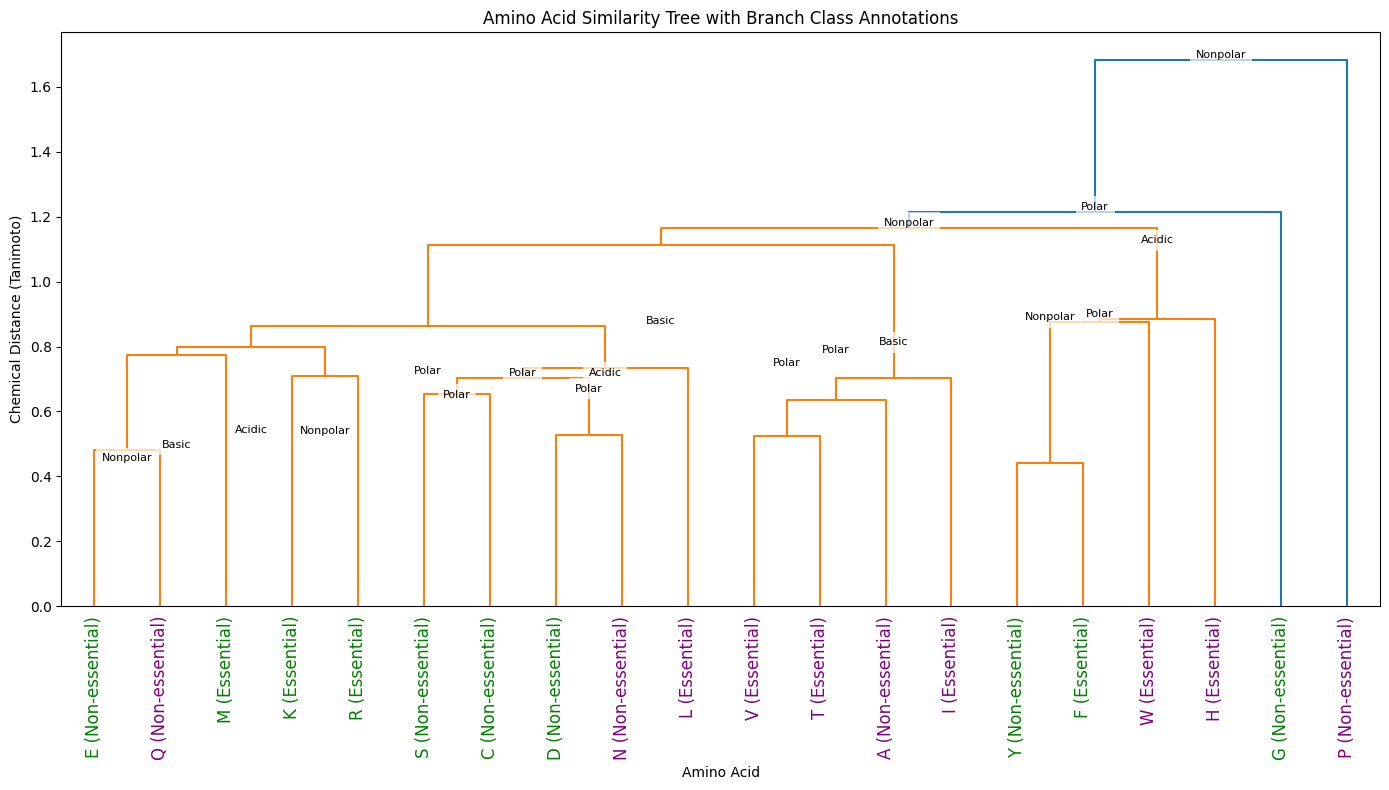

In [ ]:
import numpy as np
from scipy.cluster.hierarchy import dendrogram

#generate the dendrogram and get linkage structure
plt.figure(figsize=(14, 8))
dendro_data = dendrogram(
    linked,
    labels=labels,
    orientation='top',
    distance_sort='descending',
    leaf_rotation=90,
    no_plot=True
)

def get_dominant_class(cluster_indices, df, class_type="Polarity"):
    cluster_classes = df.iloc[cluster_indices][class_type]
    dominant_class = cluster_classes.mode()[0]
    return dominant_class


ax = plt.gca()
for i, (merge_point, children) in enumerate(zip(linked[:, 2], dendro_data['icoord'])):
    #get indices of merged clusters
    left_child = int(linked[i, 0])
    right_child = int(linked[i, 1])

    #all leaves under this merge
    left_leaves = dendro_data['leaves'][:left_child] if left_child < len(labels) else [left_child - len(labels)]
    right_leaves = dendro_data['leaves'][:right_child] if right_child < len(labels) else [right_child - len(labels)]

    #dominant class
    dominant_class = get_dominant_class(left_leaves + right_leaves, df_aa, "Polarity")

    # pos the label at the merge point
    x_pos = np.mean(children[1:3])
    y_pos = merge_point

    ax.text(
        x_pos, y_pos, dominant_class,
        ha='center', va='bottom',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'),
        fontsize=8
    )

    modified_labels = [
    f"{aa} ({df_aa[df_aa['Code'] == aa]['Essentiality'].values[0]})"
    for aa in labels
]

essentiality_colors = {
    "Essential": "purple",
    "Non-essential": "green"
}

label_colors = [essentiality_colors[df_aa[df_aa['Code'] == aa]['Essentiality'].values[0]] for aa in labels]

dendrogram(
    linked,
    labels=modified_labels,
    orientation='top',
    distance_sort='descending',
    leaf_rotation=90,
    ax=ax
)

xlbls = ax.get_xmajorticklabels()

for lbl, color in zip(xlbls, label_colors):
    lbl.set_color(color)

plt.title("Amino Acid Similarity Tree with Branch Class Annotations")
plt.xlabel("Amino Acid")
plt.ylabel("Chemical Distance (Tanimoto)")
plt.tight_layout()
plt.show()

---
# Chemical evolution between biotic and abiotic molecules

[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerator
[22:17:31] DEPRECATION WARNING: please use MorganGenerat

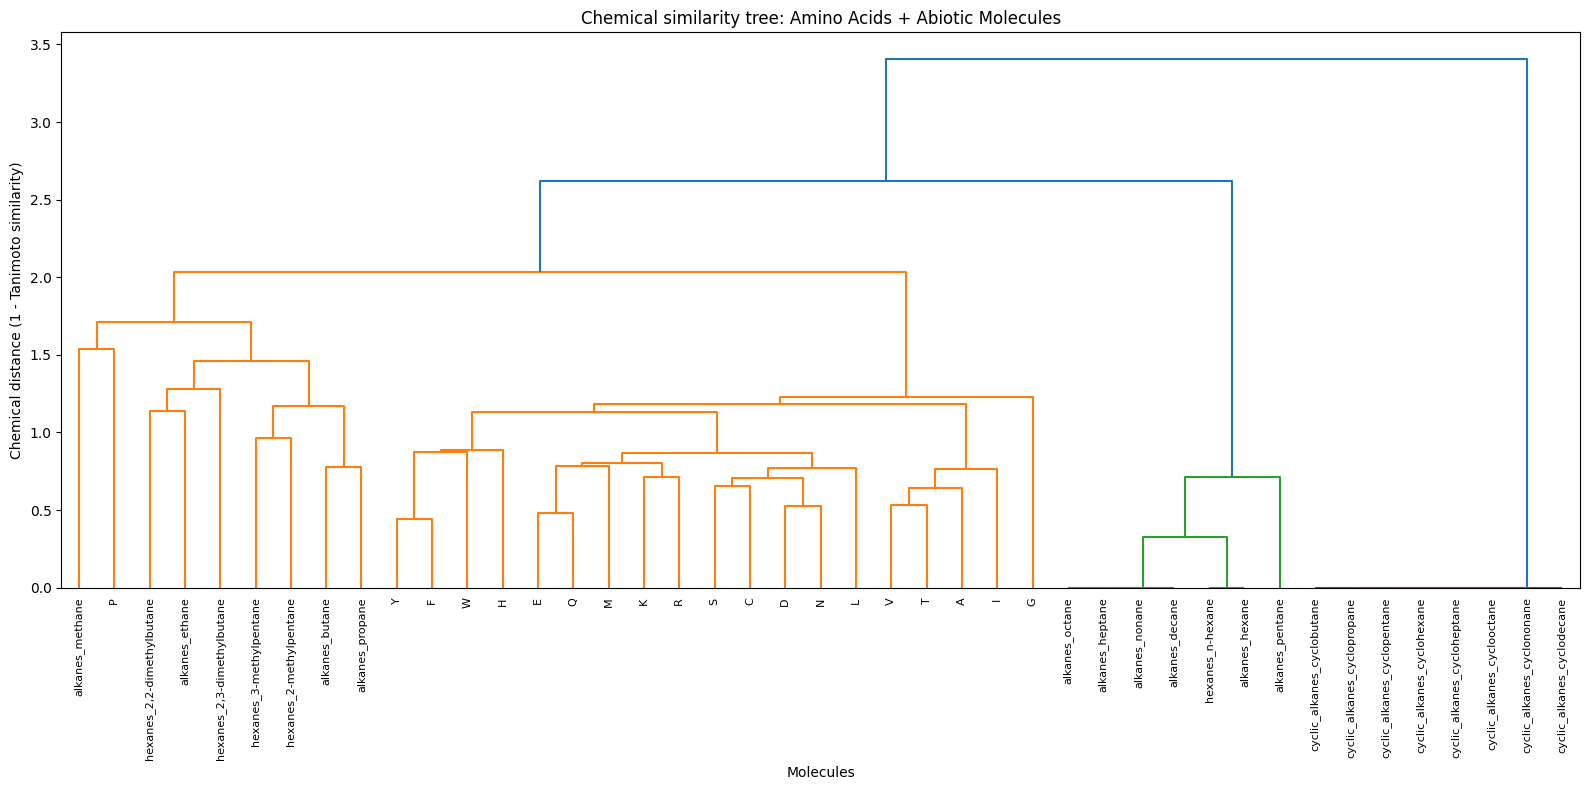

In [ ]:
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
import numpy as np

all_fps = []
all_labels = []

# amino acids first
for aa, smi in aasmiles.items():
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
    all_fps.append(fp)
 #   all_labels.append(f"AA_{aa}")
    all_labels.append(aa)

# nooow abiotic molecules
for classMol, molecules in abiotic_molecules.items():
    for name, smiles in molecules.items():
        mol = Chem.MolFromSmiles(smiles)
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=1024)
        all_fps.append(fp)
        all_labels.append(f"{classMol}_{name}")
#        all_labels.append(f"AB_{classMol}_{name}")

n = len(all_fps)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = 1 - DataStructs.TanimotoSimilarity(all_fps[i], all_fps[j])

linked = linkage(sim_matrix, method='average')

plt.figure(figsize=(16, 8))
dendrogram(linked,
           labels=all_labels,
           orientation='top',
           distance_sort='descending',
           leaf_rotation=90)
plt.title("Chemical similarity tree: Amino Acids + Abiotic Molecules")
plt.xlabel("Molecules")
plt.ylabel("Chemical distance (1 - Tanimoto similarity)")
plt.tight_layout()
plt.show()